# Colab Setup (Required for Google Colab)

**These cells are ONLY for running on Google Colab. Skip if running locally.**

In [ ]:
# access TFRecords from Practical 1
from google.colab import drive
import os

drive.mount('/content/drive')

TFRECORDS_DIR = '/content/drive/MyDrive/my_tfrecords_2018'

if not os.path.exists(TFRECORDS_DIR):
    print("TFRecords not found!")
else:
    import glob
    tfrecords = glob.glob(f"{TFRECORDS_DIR}/*.tfrecords")
    print(f"Found {len(tfrecords)} TFRecord files")

Mounted at /content/drive
Found 16 TFRecord files


In [ ]:
!git clone https://github.com/snath-xoc/cGAN_tutorial.git
%cd cGAN_tutorial

Cloning into 'cGAN_tutorial'...
remote: Enumerating objects: 252, done.
remote: Counting objects: 100% (252/252), done.
remote: Compressing objects: 100% (198/198), done.
remote: Total 252 (delta 124), reused 167 (delta 53), pack-reused 0 (from 0)
Receiving objects: 100% (252/252), 7.54 MiB | 23.41 MiB/s, done.
Resolving deltas: 100% (124/124), done.
/content/cGAN_tutorial


In [ ]:
!pip install -q xarray netCDF4 gcsfs joblib pyyaml tensorflow cartopy wandb properscoring

!pip uninstall -y crcmod
!pip install --no-cache-dir -U crcmod

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 86.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 74.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for crcmod: filename=crcmod-1.7-cp312-cp312-linux_x86_64.whl size=31833 sha256=a1ab12504292f5363b33fd2207faada4a654bebb5553f1ef7c69b3c295c27199
  Stored in directory: /tmp/pip-ephem-wheel-cache-op525rru/wheels/76/08/0b/caa8b1380122cbfe6a03eaccbec0f63c67e619af4e30ca5e2a
Successfully built crcmod


### Download Constants Files

Download elevation and land-sea mask data (same files from Practical 1).

In [ ]:
# Create constants directory and download constants
CONSTANTS_DIR = "/content/constants/"
os.makedirs(CONSTANTS_DIR, exist_ok=True)

!gsutil cp gs://sewaa-ifs-train/constants/elev.nc {CONSTANTS_DIR}
!gsutil cp gs://sewaa-ifs-train/constants/lsm.nc {CONSTANTS_DIR}

!ls -lh {CONSTANTS_DIR}

Copying gs://sewaa-ifs-train/constants/elev.nc...
- [1 files][541.8 KiB/541.8 KiB]                                                
Operation completed over 1 objects/541.8 KiB.                                    
Copying gs://sewaa-ifs-train/constants/lsm.nc...
- [1 files][540.9 KiB/540.9 KiB]                                                
Operation completed over 1 objects/540.9 KiB.                                    
total 1.1M
-rw-r--r-- 1 root root 542K Feb 17 21:19 elev.nc
-rw-r--r-- 1 root root 541K Feb 17 21:19 lsm.nc


In [ ]:
data_paths_content = f"""COLAB_STUDENT:
  GENERAL:
    tfrecords_path: "{TFRECORDS_DIR}/"
    TRUTH_PATH: "/content/raw_imerg/"
    FORECAST_PATH: "/content/raw_ifs/"
    CONSTANTS_PATH: "{CONSTANTS_DIR}"
  TFRecords:
    tfrecords_path: "{TFRECORDS_DIR}/"
"""

with open('config/data_paths.yaml', 'w') as f:
    f.write(data_paths_content)

local_config_content = """data_paths: 'COLAB_STUDENT'
gpu: false
"""

with open('config/local_config.yaml', 'w') as f:
    f.write(local_config_content)

### Create Model Checkpoint Directory

**Choose where to save model checkpoints:**
- **Demo run**: Save to Colab disk (temporary, fast)
- **2-hour run**: Save to Drive (persistent, slower)

In [ ]:
# checkpoint location

# Option 1: Colab disk
LOG_FOLDER = "/content/cgan_logs/"

# Option 2: Google drive
# LOG_FOLDER = "/content/drive/MyDrive/cgan_logs/"

os.makedirs(LOG_FOLDER, exist_ok=True)
os.makedirs(f"{LOG_FOLDER}models/", exist_ok=True)

### Update Config file


In [ ]:
import yaml

with open('config/config.yaml', 'r') as f:
    config = yaml.safe_load(f)


config['SETUP']['log_folder'] = LOG_FOLDER

# write back
with open('config/config.yaml', 'w') as f:
    yaml.dump(config, f)

# Import all packages and set paths and environment attributes

In [ ]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import gc
import json

from tensorflow import config as tf_config
import sys
import joblib
sys.path.insert(1,"../")

import yaml
from pathlib import Path

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import pandas as pd

from config import set_gpu_mode

# don't import setupdata, setupmodel, data, or evaluation here will be imported after patching

### Override all_fcst_fields and DEFAULT_FCST_SHAPE



In [ ]:
# Patch data
import data

FORECAST_VARIABLES = ['tp', 't2m', 'tcwv', 'sp']
data.all_fcst_fields.clear()
data.all_fcst_fields.extend(FORECAST_VARIABLES)

all_fcst_fields = data.all_fcst_fields

# patch DEFAULT_FCST_SHAPE in tfrecords_generator
from data import tfrecords_generator
tfrecords_generator.DEFAULT_FCST_SHAPE = (128, 128, 4 * len(FORECAST_VARIABLES))

# patch create_mixed_dataset
# Save original function only once
if not hasattr(tfrecords_generator, '_original_create_mixed'):
    tfrecords_generator._original_create_mixed = tfrecords_generator.create_mixed_dataset

def create_mixed_dataset_patched(years, batch_size, fcst_shape=None, con_shape=None,
                                 out_shape=None, repeat=True, autocoarsen=False,
                                 folder=None, shuffle_size=64, weights=None):
    # Use correct defaults for 4 variables
    if fcst_shape is None:
        fcst_shape = (128, 128, 16)
    if con_shape is None:
        con_shape = (128, 128, 2)
    if out_shape is None:
        out_shape = (128, 128, 1)
    if folder is None:
        folder = tfrecords_generator.records_folder

    return tfrecords_generator._original_create_mixed(
        years, batch_size, fcst_shape, con_shape, out_shape,
        repeat, autocoarsen, folder, shuffle_size, weights
    )

# Replace
tfrecords_generator.create_mixed_dataset = create_mixed_dataset_patched


# import setupdata and setupmodel
import setupdata
import setupmodel

### Download Validation Data (for visualization)



In [ ]:
# (9 mins)
import os

RAW_IFS_DIR = "/content/raw_ifs/2018/"
RAW_IMERG_DIR = "/content/raw_imerg/2018/"
os.makedirs(RAW_IFS_DIR, exist_ok=True)
os.makedirs(RAW_IMERG_DIR, exist_ok=True)

FORECAST_VARIABLES = ['tp', 't2m', 'tcwv', 'sp']

fcst_norm_exists = os.path.exists(f"{CONSTANTS_DIR}/FCSTNorm2018.pkl")
ifs_exists = all(os.path.exists(f"{RAW_IFS_DIR}/{var}.nc") for var in FORECAST_VARIABLES)
imerg_exists = os.path.exists(RAW_IMERG_DIR) and len(os.listdir(RAW_IMERG_DIR)) > 0

if fcst_norm_exists and ifs_exists and imerg_exists:
    print("Validation data already exists")

else:
    print("Downloading validation data")

    # Download normalization constants
    if not fcst_norm_exists:
        print("1. Downloading normalization constants...")
        !gsutil cp gs://sewaa-ifs-train/constants/FCSTNorm_IFS/FCSTNorm2018.pkl {CONSTANTS_DIR}
    else:
        print("1. Normalization constants already exist")

    # Download IFS forecast files (4 variables)
    if not ifs_exists:
        print("\n2. Downloading IFS forecast data...")
        for var in FORECAST_VARIABLES:
            if not os.path.exists(f"{RAW_IFS_DIR}/{var}.nc"):
                print(f" Downloading {var}.nc")
                !gsutil -m cp gs://sewaa-ifs-train/2018/{var}.nc {RAW_IFS_DIR}
            else:
                print(f" {var}.nc already exists")
    else:
        print("\n2. IFS forecast data already exists")

    # Download IMERG data
    if not imerg_exists:
        print("\n3. Downloading IMERG truth data")
        !gsutil -m cp -r gs://bucket_shruti_imerg/6h/2018/ {RAW_IMERG_DIR}/../
    else:
        print("\n3. IMERG truth data already exists")

1. Downloading normalization constants...
Copying gs://sewaa-ifs-train/constants/FCSTNorm_IFS/FCSTNorm2018.pkl...
/ [1 files][  1.3 KiB/  1.3 KiB]                                                
Operation completed over 1 objects/1.3 KiB.                                      

2. Downloading IFS forecast data...
Copying gs://sewaa-ifs-train/2018/tp.nc...
- [1/1 files][  6.2 GiB/  6.2 GiB] 100% Done  74.8 MiB/s ETA 00:00:00           
Operation completed over 1 objects/6.2 GiB.                                      
Copying gs://sewaa-ifs-train/2018/t2m.nc...
/ [1/1 files][  6.8 GiB/  6.8 GiB] 100% Done  68.1 MiB/s ETA 00:00:00           
Operation completed over 1 objects/6.8 GiB.                                      
Copying gs://sewaa-ifs-train/2018/tcwv.nc...
\ [1/1 files][  7.3 GiB/  7.3 GiB] 100% Done  38.9 MiB/s ETA 00:00:00           
Operation completed over 1 objects/7.3 GiB.                                      
Copying gs://sewaa-ifs-train/2018/sp.nc...
| [1/1 files][  6.5 Gi

In [ ]:
# load the forecast normalization dictionary into the data module
import pickle

fcstnorm_path = f"{CONSTANTS_DIR}/FCSTNorm2018.pkl"

if os.path.exists(fcstnorm_path):
    with open(fcstnorm_path, 'rb') as f:
        fcst_norm_dict = pickle.load(f)

    # set it in the data.data module where load_fcst() looks for it
    from data import data as data_module
    data_module.fcst_norm = fcst_norm_dict

    print(f"Loaded fcst_norm with {len(fcst_norm_dict)} variables")
else:
    print(f"{fcstnorm_path} not found")

Loaded fcst_norm with 14 variables


# Check whether GPU is available or not

In [ ]:
gpu_devices = tf_config.list_physical_devices('GPU')

print(gpu_devices)

if len(gpu_devices) == 0:
    print('GPU devices are not being seen')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Load in configuration files for this you need to specify the path to the configuration file to use, typically this will be config/config.yaml

## Please refer to the README under [model/](https://github.com/snath-xoc/cGAN_tutorial/tree/main/model) for information. Most importantly the model configuration will specify:
### 1) mode: between GAN, VAEGAN and det <br> 2) arch: between forceconv, forceconv-long and normal <br> 3) filters_gen and filters_disc: width of generator and discriminator network <br> 4) lr_gen and lr_disc: learning rate for generator and discriminator <br> 5) train_years and val_years: training and validation years to use <br> 6) num_samples: no. of samples to train on <br> 7) steps_per_checkpoint: number of batches per checkpoint save <br> 8) batch_size: size of batches <br> 9) CLtype: between CRPS, CRPS_phys, ensmeanMSE, ensmeanMSE_phys <br> 10) content_loss_weight: how much to weight content loss in loss calculation <br> 11) training_weights: training weights to assign when sampling each bin used in tfrecord creation

In [ ]:
# Path to config
config_path = "config/config.yaml"

with open(config_path, "r") as f:
    try:
        setup_params = yaml.safe_load(f)
        # print(setup_params)
    except yaml.YAMLError as exc:
        print(exc)

mode = setup_params["GENERAL"]["mode"]
arch = setup_params["MODEL"]["architecture"]
padding = setup_params["MODEL"]["padding"]
log_folder = setup_params["SETUP"]["log_folder"]
problem_type = setup_params["GENERAL"]["problem_type"]
filters_gen = setup_params["GENERATOR"]["filters_gen"]
lr_gen = setup_params["GENERATOR"]["learning_rate_gen"]
noise_channels = setup_params["GENERATOR"]["noise_channels"]
latent_variables = setup_params["GENERATOR"]["latent_variables"]
filters_disc = setup_params["DISCRIMINATOR"]["filters_disc"]
lr_disc = setup_params["DISCRIMINATOR"]["learning_rate_disc"]
train_years = setup_params["TRAIN"]["train_years"]
training_weights = setup_params["TRAIN"]["training_weights"]
num_samples = setup_params["TRAIN"]["num_samples"]
steps_per_checkpoint = setup_params["TRAIN"]["steps_per_checkpoint"]
batch_size = setup_params["TRAIN"]["batch_size"]
kl_weight = setup_params["TRAIN"]["kl_weight"]
ensemble_size = setup_params["TRAIN"]["ensemble_size"]
CLtype = setup_params["TRAIN"]["CL_type"]
content_loss_weight = setup_params["TRAIN"]["content_loss_weight"]
val_years = setup_params["VAL"]["val_years"]
val_size = setup_params["VAL"]["val_size"]
num_images = setup_params["EVAL"]["num_batches"]
add_noise = setup_params["EVAL"]["add_postprocessing_noise"]
noise_factor = setup_params["EVAL"]["postprocessing_noise_factor"]
max_pooling = setup_params["EVAL"]["max_pooling"]
avg_pooling = setup_params["EVAL"]["avg_pooling"]
constant_fields = 2

# Convert string values to float
lr_gen = float(lr_gen)
lr_disc = float(lr_disc)
kl_weight = float(kl_weight)
noise_factor = float(noise_factor)
content_loss_weight = float(content_loss_weight)

print("Loaded in the configuration for model training from:", config_path)
print("\n Model details are as follows,\n mode:",mode, "\n arch:", arch, "\n filters_gen:", filters_gen, "\n filters_disc:", filters_disc)
print("\n Training details are as follows,\n lr_gen:", lr_gen, "\n lr_disc:", lr_disc, "\n train_years:", train_years, "\n val_years:", val_years,
     "\n CLtype:", CLtype, "\n content_loss_weight:", content_loss_weight)
print("\n During training the following protocol will be used, \n num_samples:", num_samples, "\n steps_per_checkpoint:", steps_per_checkpoint,
      "\n batch_size:", batch_size, "\n training_weights:", training_weights)



Loaded in the configuration for model training from: config/config.yaml

 Model details are as follows,
 mode: GAN 
 arch: forceconv 
 filters_gen: 128 
 filters_disc: 512

 Training details are as follows,
 lr_gen: 0.0001 
 lr_disc: 0.0001 
 train_years: [2018] 
 val_years: 2018 
 CLtype: ensmeanMSE 
 content_loss_weight: 1000.0

 During training the following protocol will be used, 
 num_samples: 640000 
 steps_per_checkpoint: 9600 
 batch_size: 2 
 training_weights: [0.4, 0.3, 0.2, 0.1]


## Set up data by calling [setupdata.setup_data](https://github.com/snath-xoc/cGAN_tutorial/blob/main/setupdata.py#L42), this will return:
### 1) batch_gen_train: training dataset created by sampling from tfrecords according to the training weights <br> 2) data_gen_valid: validation dataset of full images to validate over the whole domain

In [ ]:
batch_gen_train, data_gen_valid = setupdata.setup_data(
            train_years=train_years,
            val_years=val_years,
            autocoarsen=False,
            weights=training_weights,
            batch_size=batch_size)

## Once again check output of validation dataset

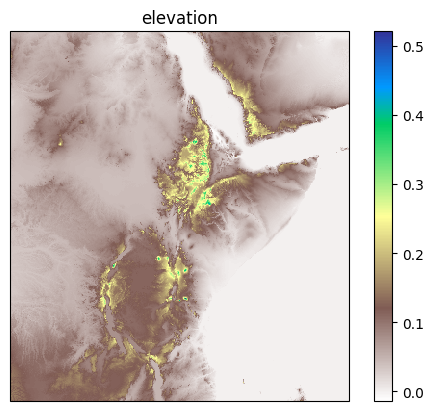

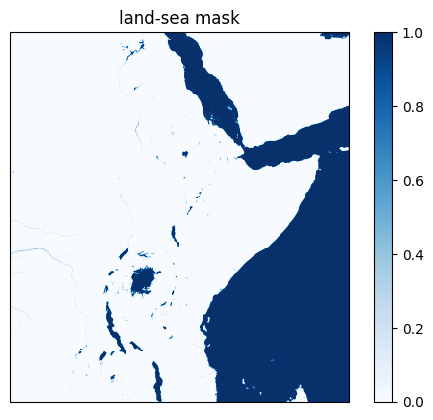

Text(0.5, 1.0, 'sp mean')

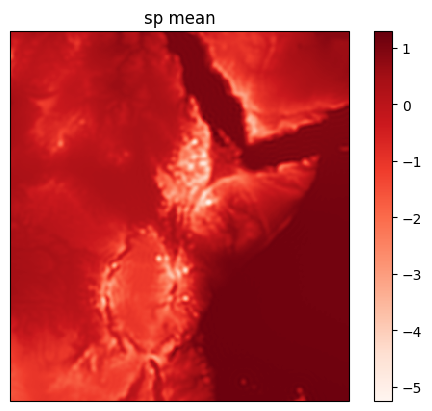

In [ ]:
sample = data_gen_valid.__getitem__(0)
ax = plt.axes(projection = ccrs.PlateCarree())

lats = np.arange(-13.65,24.65+0.1,0.1)
lons = np.arange(19.15,54.25+0.1,0.1)

mesh = ax.pcolormesh(lons, lats, sample[0]['hi_res_inputs'][0,:,:,0], cmap='terrain_r')
plt.colorbar(mesh)
plt.title('elevation')
plt.show()
plt.close()

ax = plt.axes(projection = ccrs.PlateCarree())

mesh = ax.pcolormesh(lons, lats, sample[0]['hi_res_inputs'][0,:,:,1], cmap='Blues')
plt.colorbar(mesh)
plt.title('land-sea mask')
plt.show()
plt.close()

idx = 4 * all_fcst_fields.index("sp")
ax = plt.axes(projection = ccrs.PlateCarree())

lats = np.arange(-13.65,24.65+0.1,0.1)
lons = np.arange(19.15,54.25+0.1,0.1)

mesh = ax.pcolormesh(lons, lats, sample[0]['lo_res_inputs'][0,:,:,idx], cmap='Reds')
plt.colorbar(mesh)
plt.title(f"sp mean")

## Now set up model for training, before doing so we also need to:
### 1) Specify the downscaling factor with which the model will work. This is set in the [config/downscaling_factor.yaml](https://github.com/snath-xoc/cGAN_tutorial/blob/main/config/downscaling_factor.yaml) and is loaded in by calling ```read_downscaling_factor```<br> 2) Calculate the number of input channels which will be number of ```all_fcst_fields*4``` (see [create_tfrecords.ipynb](https://github.com/snath-xoc/cGAN_tutorial/blob/main/example_notebooks/create_tfrecords.ipynb) for more explanation)

In [ ]:
from config import read_downscaling_factor

df_dict = read_downscaling_factor()

print("Downscaling factor to be used is:", df_dict["downscaling_factor"], "with steps:", df_dict["steps"])

input_channels = 4 * len(all_fcst_fields)

print("Number of input channels are:", input_channels)

Downscaling factor to be used is: 1 with steps: [1]
Number of input channels are: 16


In [ ]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
print("Setting up model")

model = setupmodel.setup_model(
            mode=mode,
            arch=arch,
            downscaling_steps=df_dict["steps"],
            input_channels=input_channels,
            constant_fields=constant_fields,
            latent_variables=latent_variables,
            filters_gen=filters_gen,
            filters_disc=filters_disc,
            noise_channels=noise_channels,
            padding=padding,
            lr_disc=lr_disc,
            lr_gen=lr_gen,
            kl_weight=kl_weight,
            ensemble_size=ensemble_size,
            CLtype=CLtype,
            content_loss_weight=content_loss_weight,
        )

Setting up model


## Now try a first training of the model, for simplicity we hard code the num_samples, steps_per_checkpoint and batch_size as this is a dry run. Once done you can check the progress plots by navigating into the folder where log results are stored (printed below)



## Training Options

**Choose one:**
- **Option A: Demo Training**
- **Option B: Full Training**



### Option A: Demo Training

In [ ]:
from model import train_model


num_samples_demo = 6
steps_per_checkpoint_demo = 3
batch_size_demo = 2

num_checkpoints = int(num_samples_demo / (steps_per_checkpoint_demo * batch_size_demo))
checkpoint = 1

print(f"Demo training: {num_checkpoints} checkpoint(s)")

if not os.path.exists(log_folder+"models/"):
    os.makedirs(log_folder+"models/")

model_weights_root = os.path.join(log_folder, "models")
training_samples = 0

while training_samples < num_samples_demo: # main training loop
    gc.collect()
    print(f"Checkpoint {checkpoint}/{num_checkpoints}")

    # train for some number of batches
    loss_log = train_model(
        model=model,
        mode=mode,
        batch_gen_train=batch_gen_train,
        data_gen_valid=data_gen_valid,
        noise_channels=noise_channels,
        latent_variables=latent_variables,
        checkpoint=checkpoint,
        steps_per_checkpoint=steps_per_checkpoint_demo,
        num_cases=val_size,
        plot_fn=os.path.join(log_folder,"progress"),
        log_wandb=False,
    )

    # Save model weights each checkpoint
    gen_weights_file = os.path.join(
        model_weights_root, f"gen_weights-{training_samples:07d}.h5"
    )
    model.gen.save_weights(gen_weights_file)

    training_samples += steps_per_checkpoint_demo * batch_size_demo
    checkpoint += 1

print("Finished")
print(f"   Checkpoints saved to: {model_weights_root}")

Demo training: 1 checkpoint(s)
Checkpoint 1/1
6/6 [==============================] - 112s 19s/step - D0: 8.3092 - D1: 1.1739 - D2: -0.9348 - D3: 0.8070 - G0: 163.5631 - G1: 4.4183 - G2: 0.1591
Finished
   Checkpoints saved to: /content/cgan_logs/models


### Option B: Full Training



In [ ]:
from model import train_model
import time

num_samples_full = 6000
steps_per_checkpoint_full = 600
batch_size_full = 2

num_checkpoints = int(num_samples_full / (steps_per_checkpoint_full * batch_size_full))
checkpoint = 1

print(f"Total samples: {num_samples_full}")
print(f"Checkpoints: {num_checkpoints}")
print(f"Log folder: {log_folder}")


if not os.path.exists(log_folder+"models/"):
    os.makedirs(log_folder+"models/")

model_weights_root = os.path.join(log_folder, "models")
training_samples = 0
start_time = time.time()

while training_samples < num_samples_full:
    gc.collect()
    print(f"\nCheckpoint {checkpoint}/{num_checkpoints}")
    print(f"Samples: {training_samples}/{num_samples_full}")

    loss_log = train_model(
        model=model,
        mode=mode,
        batch_gen_train=batch_gen_train,
        data_gen_valid=data_gen_valid,
        noise_channels=noise_channels,
        latent_variables=latent_variables,
        checkpoint=checkpoint,
        steps_per_checkpoint=steps_per_checkpoint_full,
        num_cases=val_size,
        plot_fn=os.path.join(log_folder,"progress"),
        log_wandb=False,
    )

    # Save model weights
    gen_weights_file = os.path.join(
        model_weights_root, f"gen_weights-{training_samples:07d}.h5"
    )
    model.gen.save_weights(gen_weights_file)

    training_samples += steps_per_checkpoint_full * batch_size_full
    checkpoint += 1

elapsed = time.time() - start_time


print(f"Total time: {elapsed/60:.1f} minutes ({elapsed/3600:.2f} hours)")
print(f"Checkpoints saved to: {model_weights_root}")
print("Finished")

## Now check that the evaluation is working

In [ ]:
!gsutil -m cp -r gs://bucket_shruti_imerg/6h/2019/ /content/raw_imerg/

Copying gs://bucket_shruti_imerg/6h/2019/20190101_00.nc...
Copying gs://bucket_shruti_imerg/6h/2019/20190102_06.nc...
Copying gs://bucket_shruti_imerg/6h/2019/20190101_12.nc...
Copying gs://bucket_shruti_imerg/6h/2019/20190101_06.nc...
Copying gs://bucket_shruti_imerg/6h/2019/20190101_18.nc...
Copying gs://bucket_shruti_imerg/6h/2019/20190102_00.nc...
Copying gs://bucket_shruti_imerg/6h/2019/20190102_18.nc...
Copying gs://bucket_shruti_imerg/6h/2019/20190103_00.nc...
Copying gs://bucket_shruti_imerg/6h/2019/20190102_12.nc...
Copying gs://bucket_shruti_imerg/6h/2019/20190103_06.nc...
Copying gs://bucket_shruti_imerg/6h/2019/20190103_12.nc...
Copying gs://bucket_shruti_imerg/6h/2019/20190103_18.nc...
Copying gs://bucket_shruti_imerg/6h/2019/20190104_00.nc...
Copying gs://bucket_shruti_imerg/6h/2019/20190104_06.nc...
Copying gs://bucket_shruti_imerg/6h/2019/20190104_18.nc...
Copying gs://bucket_shruti_imerg/6h/2019/20190104_12.nc...
Copying gs://bucket_shruti_imerg/6h/2019/20190105_06.nc.

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 37 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12 [186 kB]
Fetched 186 kB in 1s (187 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up poppler-utils (22.02.0-2ubuntu0.12) ...
Processing triggers for man-db (2.10.2-1) ...


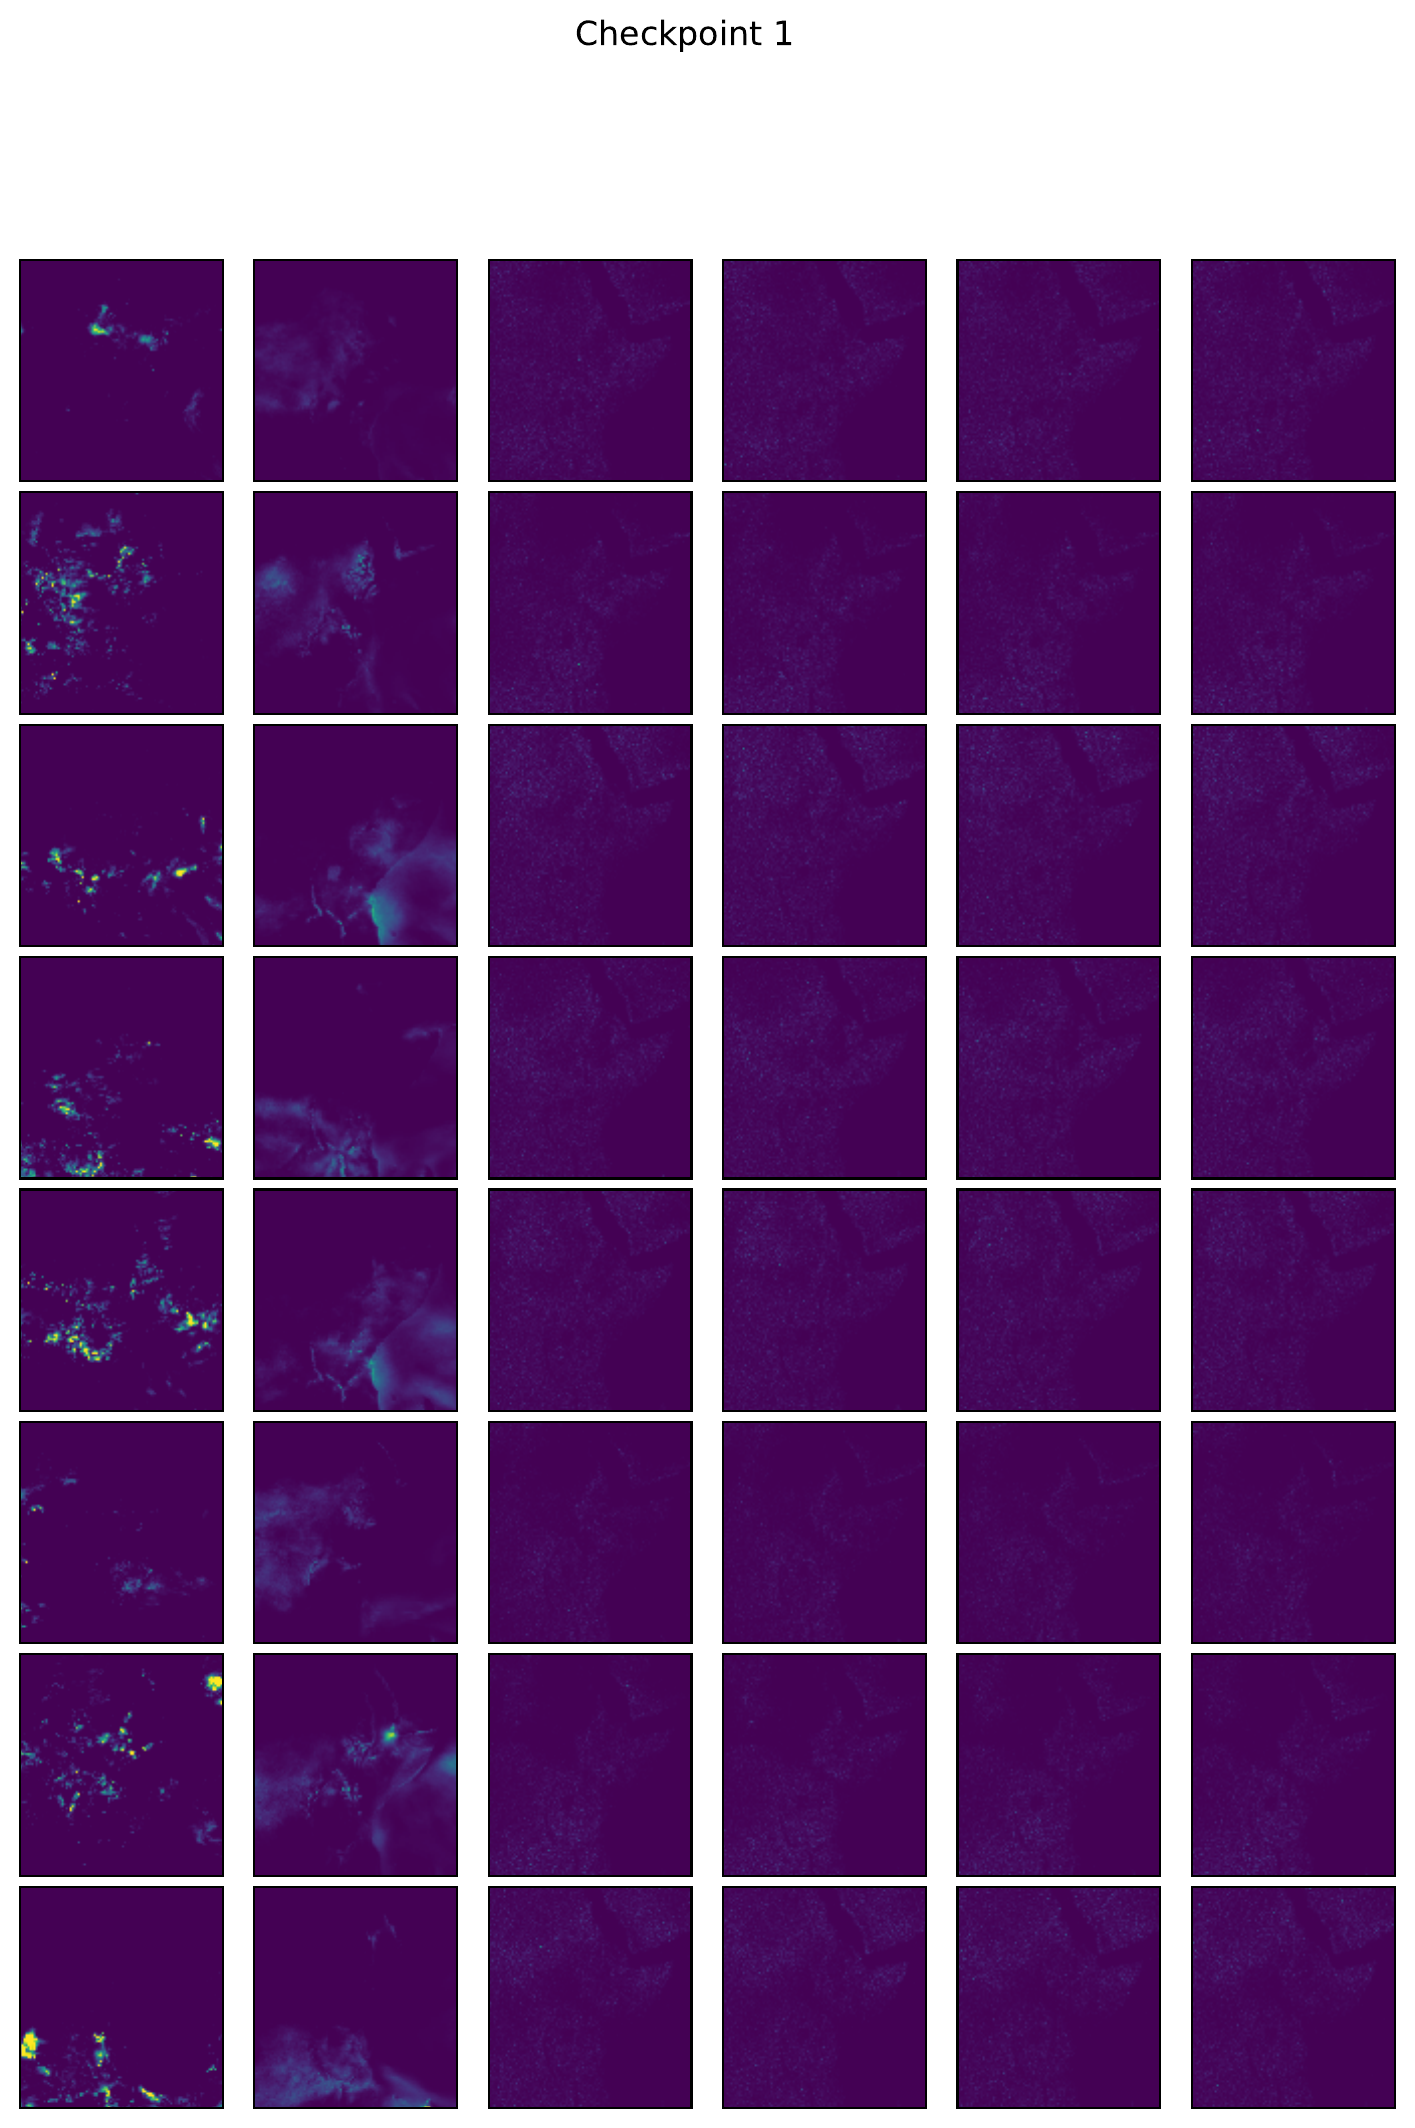

In [ ]:
!apt-get install -y poppler-utils
!pip install pdf2image

from pdf2image import convert_from_path
from IPython.display import display

images = convert_from_path("/content/cgan_logs/progress_1.pdf")

for img in images:
    display(img)

In [ ]:
# import evaluation module (avoided earlier to prevent circular import) (26 mins)
from evaluation import evaluate_multiple_checkpoints

eval_fname = os.path.join(log_folder, "eval_validation.txt")
print("Generating evaluation report to be stored in", eval_fname)

evaluate_multiple_checkpoints(
            mode=mode,
            arch=arch,
            val_years=val_years,
            log_fname=eval_fname,
            weights_dir=model_weights_root,
            autocoarsen=False,
            add_noise=add_noise,
            noise_factor=noise_factor,
            model_numbers=[0],
            ranks_to_save=[],
            num_images=num_images,
            filters_gen=filters_gen,
            filters_disc=filters_disc,
            input_channels=input_channels,
            constant_fields=constant_fields,
            latent_variables=latent_variables,
            noise_channels=noise_channels,
            padding=padding,
            ensemble_size=10,
        )

print("Finished")

Generating evaluation report to be stored in /content/cgan_logs/eval_validation.txt
Loading full sized image dataset
/content/cgan_logs/models/gen_weights-0000000.h5
256/256 [==============================] - 1602s 6s/step - EM-RMSE: 0.4927 - CRPS: 0.1244
Finished


## View Evaluation Results

In [ ]:
with open(eval_fname, 'r') as f:
    eval_results = f.read()
    print(eval_results)

Number of images: 256
Samples per image: 10
Data initial dates/time indices: ['20180728' '20180830' '20180416' '20181218'], [48 30 48 42],gen seed 9999
N CRPS CRPS_max_4 CRPS_max_16 CRPS_avg_4 CRPS_avg_16 RMSE EMRMSE RALSD MAE OPL OPR
Number of images: 256
Samples per image: 10
Data initial dates/time indices: ['20180919' '20180104' '20181016' '20180318'], [36 36 36 48],gen seed 9999
N CRPS CRPS_max_4 CRPS_max_16 CRPS_avg_4 CRPS_avg_16 RMSE EMRMSE RALSD MAE OPL OPR
0 0.124438 0.303681 0.824849 0.134415 0.129307 0.481030 0.476717 12.112827 0.147893 0.852201 0.096210




## Now you can go check the evaluation results under the eval_validation.txt file in you log folder. For further training of the cGAN using the command line options is recommended. See the README under [model/](https://github.com/snath-xoc/cGAN_tutorial/tree/main/model) for more information
